## Schema Relationship Analyzer

This notebook discovers **primary key / foreign key relationships** between tables in one or more specified schemas using a **layered approach**:

1. **Formal Constraints** — Query `information_schema` for explicitly defined PK/FK constraints (confidence: 1.0)
2. **Smart Heuristics** — Infer relationships via exact/fuzzy column name matching, table-name-in-column detection, data type compatibility, and value overlap analysis (confidence: 0.6–0.8)
3. **LLM Semantic Analysis** — Use a foundation model to identify ambiguous or missed relationships from schema metadata (confidence: varies)

Results are written to a Delta table in your target catalog/schema with a logical name derived from the input schemas.

In [0]:
# --- Input Parameters ---
dbutils.widgets.text("input_schemas", "samples.tpch", "Input Schemas (comma-separated catalog.schema)")
dbutils.widgets.text("output_catalog", "aira_test", "Output Catalog")
dbutils.widgets.text("output_schema", "aibi_workshop_schema", "Output Schema")

# --- Parse parameters ---
raw_schemas = dbutils.widgets.get("input_schemas")
output_catalog = dbutils.widgets.get("output_catalog")
output_schema = dbutils.widgets.get("output_schema")

# Parse comma-separated schemas into list of (catalog, schema) tuples
input_schemas = []
for s in raw_schemas.split(","):
    s = s.strip()
    if "." in s:
        parts = s.split(".")
        input_schemas.append((parts[0].strip(), parts[1].strip()))
    else:
        print(f"WARNING: Skipping invalid schema '{s}' \u2014 expected format: catalog.schema")

if not input_schemas:
    raise ValueError("No valid input schemas provided. Use format: catalog.schema")

# Generate logical output table name from schema names
schema_names = [schema for _, schema in input_schemas]
output_table_name = "_".join(schema_names) + "_table_relationships"
output_full_name = f"{output_catalog}.{output_schema}.{output_table_name}"

print(f"Input schemas:  {input_schemas}")
print(f"Output table:   {output_full_name}")

Input schemas:  [('samples', 'tpch')]
Output table:   aira_test.aibi_workshop_schema.tpch_table_relationships


In [0]:
from pyspark.sql import functions as F

# Dictionary: (catalog, schema) -> { table_name: [{name, type, comment}, ...] }
all_metadata = {}

for catalog, schema in input_schemas:
    key = f"{catalog}.{schema}"
    all_metadata[key] = {}

    try:
        tables = spark.catalog.listTables(f"{catalog}.{schema}")
    except Exception as e:
        print(f"WARNING: Could not list tables in {key}: {e}")
        continue

    for tbl in tables:
        table_full = f"{catalog}.{schema}.{tbl.name}"
        try:
            columns = spark.catalog.listColumns(table_full)
            col_info = []
            for col in columns:
                col_info.append({
                    "name": col.name,
                    "type": col.dataType,
                    "comment": col.description or "",
                    "nullable": getattr(col, "nullable", True)
                })
            all_metadata[key][tbl.name] = col_info
        except Exception as e:
            print(f"WARNING: Could not read columns for {table_full}: {e}")

# Print summary
print("=" * 60)
print("METADATA SUMMARY")
print("=" * 60)
total_tables = 0
total_columns = 0
for schema_key, tables in all_metadata.items():
    print(f"\n  Schema: {schema_key}")
    for tbl_name, cols in tables.items():
        print(f"    {tbl_name:30s} \u2014 {len(cols)} columns")
        total_tables += 1
        total_columns += len(cols)
print(f"\n  Total: {total_tables} tables, {total_columns} columns")

METADATA SUMMARY

  Schema: samples.tpch
    customer                       — 8 columns
    lineitem                       — 16 columns
    nation                         — 4 columns
    orders                         — 9 columns
    part                           — 9 columns
    partsupp                       — 5 columns
    region                         — 3 columns
    supplier                       — 7 columns

  Total: 8 tables, 61 columns


In [0]:
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

# Schema for all relationship DataFrames
rel_schema = StructType([
    StructField("source_catalog", StringType()),
    StructField("source_schema", StringType()),
    StructField("source_table", StringType()),
    StructField("source_column", StringType()),
    StructField("target_catalog", StringType()),
    StructField("target_schema", StringType()),
    StructField("target_table", StringType()),
    StructField("target_column", StringType()),
    StructField("relationship_type", StringType()),
    StructField("confidence_score", DoubleType()),
    StructField("detected_by", StringType()),
])

formal_rows = []

for catalog, schema in input_schemas:
    try:
        query = f"""
        SELECT
            tc.table_catalog   AS source_catalog,
            tc.table_schema    AS source_schema,
            tc.table_name      AS source_table,
            kcu.column_name    AS source_column,
            kcu2.table_catalog AS target_catalog,
            kcu2.table_schema  AS target_schema,
            kcu2.table_name    AS target_table,
            kcu2.column_name   AS target_column
        FROM {catalog}.information_schema.table_constraints tc
        JOIN {catalog}.information_schema.key_column_usage kcu
            ON tc.constraint_catalog = kcu.constraint_catalog
            AND tc.constraint_schema = kcu.constraint_schema
            AND tc.constraint_name = kcu.constraint_name
        JOIN {catalog}.information_schema.referential_constraints rc
            ON tc.constraint_catalog = rc.constraint_catalog
            AND tc.constraint_schema = rc.constraint_schema
            AND tc.constraint_name = rc.constraint_name
        JOIN {catalog}.information_schema.key_column_usage kcu2
            ON rc.unique_constraint_catalog = kcu2.constraint_catalog
            AND rc.unique_constraint_schema = kcu2.constraint_schema
            AND rc.unique_constraint_name = kcu2.constraint_name
        WHERE tc.constraint_type = 'FOREIGN KEY'
            AND tc.table_schema = '{schema}'
        """
        result = spark.sql(query).collect()
        for row in result:
            formal_rows.append((
                row.source_catalog, row.source_schema, row.source_table, row.source_column,
                row.target_catalog, row.target_schema, row.target_table, row.target_column,
                "foreign_key", 1.0, "information_schema"
            ))
    except Exception as e:
        print(f"WARNING: Could not query information_schema for {catalog}.{schema}: {e}")

formal_df = spark.createDataFrame(formal_rows, schema=rel_schema)

formal_count = formal_df.count()
print(f"Formal PK/FK relationships found: {formal_count}")
if formal_count > 0:
    display(formal_df)
else:
    print("No formal constraints defined — proceeding to heuristic inference.")

Formal PK/FK relationships found: 0
No formal constraints defined — proceeding to heuristic inference.


In [0]:
import itertools
from difflib import SequenceMatcher

def type_compatible(type_a, type_b):
    """Check if two Spark SQL data types are compatible for a join relationship."""
    numeric_types = {"int", "bigint", "long", "smallint", "tinyint", "integer", "short", "byte"}
    string_types = {"string", "varchar", "char"}
    a, b = type_a.lower(), type_b.lower()
    if a == b:
        return True
    if a in numeric_types and b in numeric_types:
        return True
    if a in string_types and b in string_types:
        return True
    return False

def fuzzy_similarity(name_a, name_b):
    """Compute similarity ratio between two column names."""
    return SequenceMatcher(None, name_a.lower(), name_b.lower()).ratio()

def check_value_overlap(spark, full_table_a, col_a, full_table_b, col_b, sample_size=1000):
    """Sample values from col_a and check what % exist in col_b.
    Returns overlap ratio (0.0 to 1.0)."""
    try:
        vals_a = (
            spark.table(full_table_a)
            .select(col_a).distinct().limit(sample_size).rdd.flatMap(lambda x: x).collect()
        )
        if not vals_a:
            return 0.0
        vals_b_set = set(
            spark.table(full_table_b)
            .select(col_b).distinct().limit(sample_size * 5).rdd.flatMap(lambda x: x).collect()
        )
        matches = sum(1 for v in vals_a if v in vals_b_set)
        return matches / len(vals_a)
    except Exception:
        return 0.0

# Build a flat list of (catalog, schema, table, col_name, col_type, comment)
all_columns = []
for schema_key, tables in all_metadata.items():
    cat, sch = schema_key.split(".")
    for tbl_name, cols in tables.items():
        for col in cols:
            all_columns.append((cat, sch, tbl_name, col["name"], col["type"], col["comment"]))

# Precompute distinct counts per column for PK detection (approximate via sample)
print("Profiling columns for uniqueness (sampling)...")
distinct_ratios = {}
for cat, sch, tbl, col_name, col_type, _ in all_columns:
    full_table = f"{cat}.{sch}.{tbl}"
    try:
        total = spark.table(full_table).limit(5000).count()
        if total == 0:
            distinct_ratios[(cat, sch, tbl, col_name)] = 0.0
            continue
        distinct_count = spark.table(full_table).select(col_name).limit(5000).distinct().count()
        distinct_ratios[(cat, sch, tbl, col_name)] = distinct_count / total
    except Exception:
        distinct_ratios[(cat, sch, tbl, col_name)] = 0.0

heuristic_rows = []
seen_pairs = set()  # Track (src_table.col, tgt_table.col) to avoid duplicates

# --- Heuristic 1 & 2: Exact and fuzzy column name matching ---
print("Running column name matching (exact + fuzzy)...")
for i, (cat_a, sch_a, tbl_a, col_a, type_a, _) in enumerate(all_columns):
    for j, (cat_b, sch_b, tbl_b, col_b, type_b, _) in enumerate(all_columns):
        if i >= j:
            continue  # Avoid self and duplicate pairs
        if tbl_a == tbl_b and sch_a == sch_b and cat_a == cat_b:
            continue  # Same table
        if not type_compatible(type_a, type_b):
            continue

        pair_key = tuple(sorted([(cat_a, sch_a, tbl_a, col_a), (cat_b, sch_b, tbl_b, col_b)]))
        if pair_key in seen_pairs:
            continue

        similarity = fuzzy_similarity(col_a, col_b)

        if similarity >= 0.75:  # Exact match gives 1.0, fuzzy >= 0.75
            # Determine direction: higher distinct ratio is likely the PK side
            ratio_a = distinct_ratios.get((cat_a, sch_a, tbl_a, col_a), 0)
            ratio_b = distinct_ratios.get((cat_b, sch_b, tbl_b, col_b), 0)

            if ratio_a >= ratio_b:
                src = (cat_b, sch_b, tbl_b, col_b)  # FK side (less unique)
                tgt = (cat_a, sch_a, tbl_a, col_a)  # PK side (more unique)
            else:
                src = (cat_a, sch_a, tbl_a, col_a)
                tgt = (cat_b, sch_b, tbl_b, col_b)

            confidence = 0.8 if similarity == 1.0 else 0.6
            method = "heuristic_exact_match" if similarity == 1.0 else "heuristic_fuzzy_match"

            seen_pairs.add(pair_key)
            heuristic_rows.append((
                src[0], src[1], src[2], src[3],
                tgt[0], tgt[1], tgt[2], tgt[3],
                "foreign_key", confidence, method
            ))

# --- Heuristic 3: Table name embedded in column name ---
print("Running table-name-in-column detection...")
table_names = set()
for schema_key, tables in all_metadata.items():
    for tbl_name in tables:
        table_names.add(tbl_name.lower())

for cat, sch, tbl, col_name, col_type, _ in all_columns:
    col_lower = col_name.lower()
    for schema_key, tables in all_metadata.items():
        ref_cat, ref_sch = schema_key.split(".")
        for ref_tbl, ref_cols in tables.items():
            if ref_tbl.lower() == tbl.lower() and ref_sch == sch and ref_cat == cat:
                continue  # Skip same table

            # Check if column name contains the referenced table name
            if ref_tbl.lower() in col_lower and len(ref_tbl) >= 3:
                # Find the likely PK in the referenced table (highest distinct ratio)
                best_pk = None
                best_ratio = -1
                for ref_col in ref_cols:
                    if not type_compatible(col_type, ref_col["type"]):
                        continue
                    r = distinct_ratios.get((ref_cat, ref_sch, ref_tbl, ref_col["name"]), 0)
                    if r > best_ratio:
                        best_ratio = r
                        best_pk = ref_col["name"]

                if best_pk and best_ratio > 0.8:
                    pair_key = tuple(sorted([
                        (cat, sch, tbl, col_name),
                        (ref_cat, ref_sch, ref_tbl, best_pk)
                    ]))
                    if pair_key not in seen_pairs:
                        seen_pairs.add(pair_key)
                        heuristic_rows.append((
                            cat, sch, tbl, col_name,
                            ref_cat, ref_sch, ref_tbl, best_pk,
                            "foreign_key", 0.7, "heuristic_table_in_col"
                        ))

# --- Heuristic 4: Value overlap boost ---
print("Checking value overlap for candidate relationships...")
for idx, row in enumerate(heuristic_rows):
    src_full = f"{row[0]}.{row[1]}.{row[2]}"
    tgt_full = f"{row[4]}.{row[5]}.{row[6]}"
    overlap = check_value_overlap(spark, src_full, row[3], tgt_full, row[7])
    current_conf = row[9]
    if overlap > 0.8:
        # Boost confidence by up to 0.15 based on overlap
        boosted = min(current_conf + 0.15, 0.99)
        heuristic_rows[idx] = row[:9] + (boosted, row[10] + "+value_overlap")
    elif overlap < 0.2:
        # Low overlap — reduce confidence significantly
        reduced = max(current_conf - 0.3, 0.1)
        heuristic_rows[idx] = row[:9] + (reduced, row[10] + "+low_overlap")

heuristic_df = spark.createDataFrame(heuristic_rows, schema=rel_schema)

heuristic_count = heuristic_df.count()
print(f"\nHeuristic relationships found: {heuristic_count}")
if heuristic_count > 0:
    display(heuristic_df.orderBy(F.desc("confidence_score")))

Profiling columns for uniqueness (sampling)...
Running column name matching (exact + fuzzy)...
Running table-name-in-column detection...
Checking value overlap for candidate relationships...

Heuristic relationships found: 53


source_catalog,source_schema,source_table,source_column,target_catalog,target_schema,target_table,target_column,relationship_type,confidence_score,detected_by
samples,tpch,orders,o_custkey,samples,tpch,customer,c_custkey,foreign_key,0.3,heuristic_fuzzy_match+low_overlap
samples,tpch,nation,n_name,samples,tpch,customer,c_name,foreign_key,0.3,heuristic_fuzzy_match+low_overlap
samples,tpch,part,p_name,samples,tpch,customer,c_name,foreign_key,0.3,heuristic_fuzzy_match+low_overlap
samples,tpch,region,r_name,samples,tpch,customer,c_name,foreign_key,0.3,heuristic_fuzzy_match+low_overlap
samples,tpch,supplier,s_name,samples,tpch,customer,c_name,foreign_key,0.3,heuristic_fuzzy_match+low_overlap
samples,tpch,supplier,s_address,samples,tpch,customer,c_address,foreign_key,0.3,heuristic_fuzzy_match+low_overlap
samples,tpch,customer,c_nationkey,samples,tpch,nation,n_nationkey,foreign_key,0.3,heuristic_fuzzy_match+low_overlap
samples,tpch,supplier,s_nationkey,samples,tpch,customer,c_nationkey,foreign_key,0.3,heuristic_fuzzy_match+low_overlap
samples,tpch,supplier,s_phone,samples,tpch,customer,c_phone,foreign_key,0.3,heuristic_fuzzy_match+low_overlap
samples,tpch,customer,c_acctbal,samples,tpch,supplier,s_acctbal,foreign_key,0.3,heuristic_fuzzy_match+low_overlap


In [0]:
import json

def build_schema_prompt(metadata):
    """Build a prompt describing all table schemas for the LLM."""
    lines = []
    for schema_key, tables in metadata.items():
        lines.append(f"Schema: {schema_key}")
        for tbl_name, cols in tables.items():
            col_descs = []
            for c in cols:
                desc = f"    - {c['name']} ({c['type']})"
                if c.get('comment'):
                    desc += f"  -- {c['comment']}"
                col_descs.append(desc)
            lines.append(f"  Table: {tbl_name}")
            lines.extend(col_descs)
        lines.append("")
    return "\n".join(lines)

def call_llm_for_relationships(metadata):
    """Use Databricks Foundation Model API to infer table relationships."""
    schema_text = build_schema_prompt(metadata)

    json_example = '[{"source_table": "orders", "source_column": "cust_id", "target_table": "customer", "target_column": "id", "confidence": 0.9, "reasoning": "cust_id references customer table"}]'

    prompt = (
        "You are a database schema analyst. Given the following table schemas, "
        "identify ALL likely primary key / foreign key relationships between tables.\n\n"
        "For each relationship, provide:\n"
        "- source_table: the table containing the foreign key\n"
        "- source_column: the foreign key column\n"
        "- target_table: the table containing the primary key\n"
        "- target_column: the primary key column\n"
        "- confidence: a score from 0.0 to 1.0\n"
        "- reasoning: brief explanation\n\n"
        "Consider:\n"
        "- Column names that suggest references to other tables\n"
        "- Data types that are compatible for joins\n"
        "- Common database design patterns\n"
        "- Column names that are semantically related even if not identical\n\n"
        "Respond ONLY with a valid JSON array. No other text.\n"
        f"Example: {json_example}\n\n"
        f"Schemas:\n{schema_text}"
    )

    try:
        from mlflow.deployments import get_deploy_client
        client = get_deploy_client("databricks")

        response = client.predict(
            endpoint="databricks-claude-sonnet-4",
            inputs={
                "messages": [
                    {"role": "user", "content": prompt}
                ],
                "max_tokens": 4096,
                "temperature": 0.1,
            },
        )

        content = response["choices"][0]["message"]["content"]
        # Extract JSON from response (handle markdown code blocks)
        content = content.strip()
        if content.startswith("```"):
            content = content.split("\n", 1)[1]
            content = content.rsplit("```", 1)[0]
        relationships = json.loads(content)
        return relationships

    except Exception as e:
        print(f"WARNING: LLM analysis failed: {e}")
        print("Skipping LLM step \u2014 using heuristic results only.")
        return []

# Run LLM analysis
print("Calling LLM for semantic relationship analysis...")
llm_results = call_llm_for_relationships(all_metadata)

# Convert LLM results to rows matching our schema
llm_rows = []
for rel in llm_results:
    try:
        # Resolve catalog and schema for each table
        src_cat, src_sch, src_tbl = None, None, rel.get("source_table", "")
        tgt_cat, tgt_sch, tgt_tbl = None, None, rel.get("target_table", "")

        # Match table names to known metadata
        for schema_key, tables in all_metadata.items():
            cat, sch = schema_key.split(".")
            for tbl_name in tables:
                if tbl_name.lower() == src_tbl.lower():
                    src_cat, src_sch = cat, sch
                if tbl_name.lower() == tgt_tbl.lower():
                    tgt_cat, tgt_sch = cat, sch

        if src_cat and tgt_cat:
            confidence = float(rel.get("confidence", 0.7))
            reasoning = rel.get("reasoning", "")
            llm_rows.append((
                src_cat, src_sch, src_tbl.lower(), rel.get("source_column", "").lower(),
                tgt_cat, tgt_sch, tgt_tbl.lower(), rel.get("target_column", "").lower(),
                "foreign_key", confidence, f"llm: {reasoning[:100]}"
            ))
    except Exception as e:
        print(f"WARNING: Could not parse LLM result: {rel} \u2014 {e}")

llm_df = spark.createDataFrame(llm_rows, schema=rel_schema) if llm_rows else spark.createDataFrame([], schema=rel_schema)

llm_count = llm_df.count()
print(f"LLM relationships found: {llm_count}")
if llm_count > 0:
    display(llm_df)

Calling LLM for semantic relationship analysis...
LLM relationships found: 9


source_catalog,source_schema,source_table,source_column,target_catalog,target_schema,target_table,target_column,relationship_type,confidence_score,detected_by
samples,tpch,customer,c_nationkey,samples,tpch,nation,n_nationkey,foreign_key,0.95,llm: c_nationkey references nation table primary key n_nationkey
samples,tpch,lineitem,l_orderkey,samples,tpch,orders,o_orderkey,foreign_key,0.95,llm: l_orderkey references orders table primary key o_orderkey
samples,tpch,lineitem,l_partkey,samples,tpch,part,p_partkey,foreign_key,0.95,llm: l_partkey references part table primary key p_partkey
samples,tpch,lineitem,l_suppkey,samples,tpch,supplier,s_suppkey,foreign_key,0.95,llm: l_suppkey references supplier table primary key s_suppkey
samples,tpch,nation,n_regionkey,samples,tpch,region,r_regionkey,foreign_key,0.95,llm: n_regionkey references region table primary key r_regionkey
samples,tpch,orders,o_custkey,samples,tpch,customer,c_custkey,foreign_key,0.95,llm: o_custkey references customer table primary key c_custkey
samples,tpch,partsupp,ps_partkey,samples,tpch,part,p_partkey,foreign_key,0.95,llm: ps_partkey references part table primary key p_partkey
samples,tpch,partsupp,ps_suppkey,samples,tpch,supplier,s_suppkey,foreign_key,0.95,llm: ps_suppkey references supplier table primary key s_suppkey
samples,tpch,supplier,s_nationkey,samples,tpch,nation,n_nationkey,foreign_key,0.95,llm: s_nationkey references nation table primary key n_nationkey


In [0]:
from pyspark.sql import Window

# Union all three sources
all_relationships = formal_df.unionByName(heuristic_df).unionByName(llm_df)

if all_relationships.count() == 0:
    print("No relationships found by any method.")
    final_df = spark.createDataFrame([], schema=rel_schema)
else:
    # Normalize column values for deduplication
    for col_name in ["source_table", "source_column", "target_table", "target_column"]:
        all_relationships = all_relationships.withColumn(col_name, F.lower(F.col(col_name)))

    # Group by relationship pair, keep highest confidence, collect all detection methods
    group_cols = [
        "source_catalog", "source_schema", "source_table", "source_column",
        "target_catalog", "target_schema", "target_table", "target_column",
        "relationship_type"
    ]

    final_df = (
        all_relationships
        .groupBy(group_cols)
        .agg(
            F.max("confidence_score").alias("confidence_score"),
            F.concat_ws(" | ", F.collect_set("detected_by")).alias("detected_by")
        )
        .orderBy(F.desc("confidence_score"))
    )

    # Remove low-confidence duplicates: if (A->B) and (B->A) exist, keep only the higher one
    # Create a canonical key for each pair
    final_df = final_df.withColumn(
        "_pair_key",
        F.when(
            F.concat(F.col("source_table"), F.col("source_column")) < F.concat(F.col("target_table"), F.col("target_column")),
            F.concat_ws("|", "source_table", "source_column", "target_table", "target_column")
        ).otherwise(
            F.concat_ws("|", "target_table", "target_column", "source_table", "source_column")
        )
    )

    window = Window.partitionBy("_pair_key").orderBy(F.desc("confidence_score"))
    final_df = (
        final_df
        .withColumn("_rank", F.row_number().over(window))
        .filter(F.col("_rank") == 1)
        .drop("_pair_key", "_rank")
        .orderBy(F.desc("confidence_score"))
    )

final_count = final_df.count()
print(f"Final deduplicated relationships: {final_count}")

Final deduplicated relationships: 53


In [0]:
if final_df.count() == 0:
    print("No relationships to write. Skipping table creation.")
else:
    try:
        # Ensure the output catalog and schema exist (they should already)
        final_df.write.format("delta").mode("overwrite").option(
            "overwriteSchema", "true"
        ).saveAsTable(output_full_name)

        row_count = spark.table(output_full_name).count()
        print(f"Successfully wrote {row_count} relationships to:")
        print(f"  {output_full_name}")
    except Exception as e:
        print(f"ERROR: Could not write output table: {e}")
        print("Displaying results inline instead.")
        display(final_df)

Successfully wrote 53 relationships to:
  aira_test.aibi_workshop_schema.tpch_table_relationships


In [0]:
%pip install networkx --quiet
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


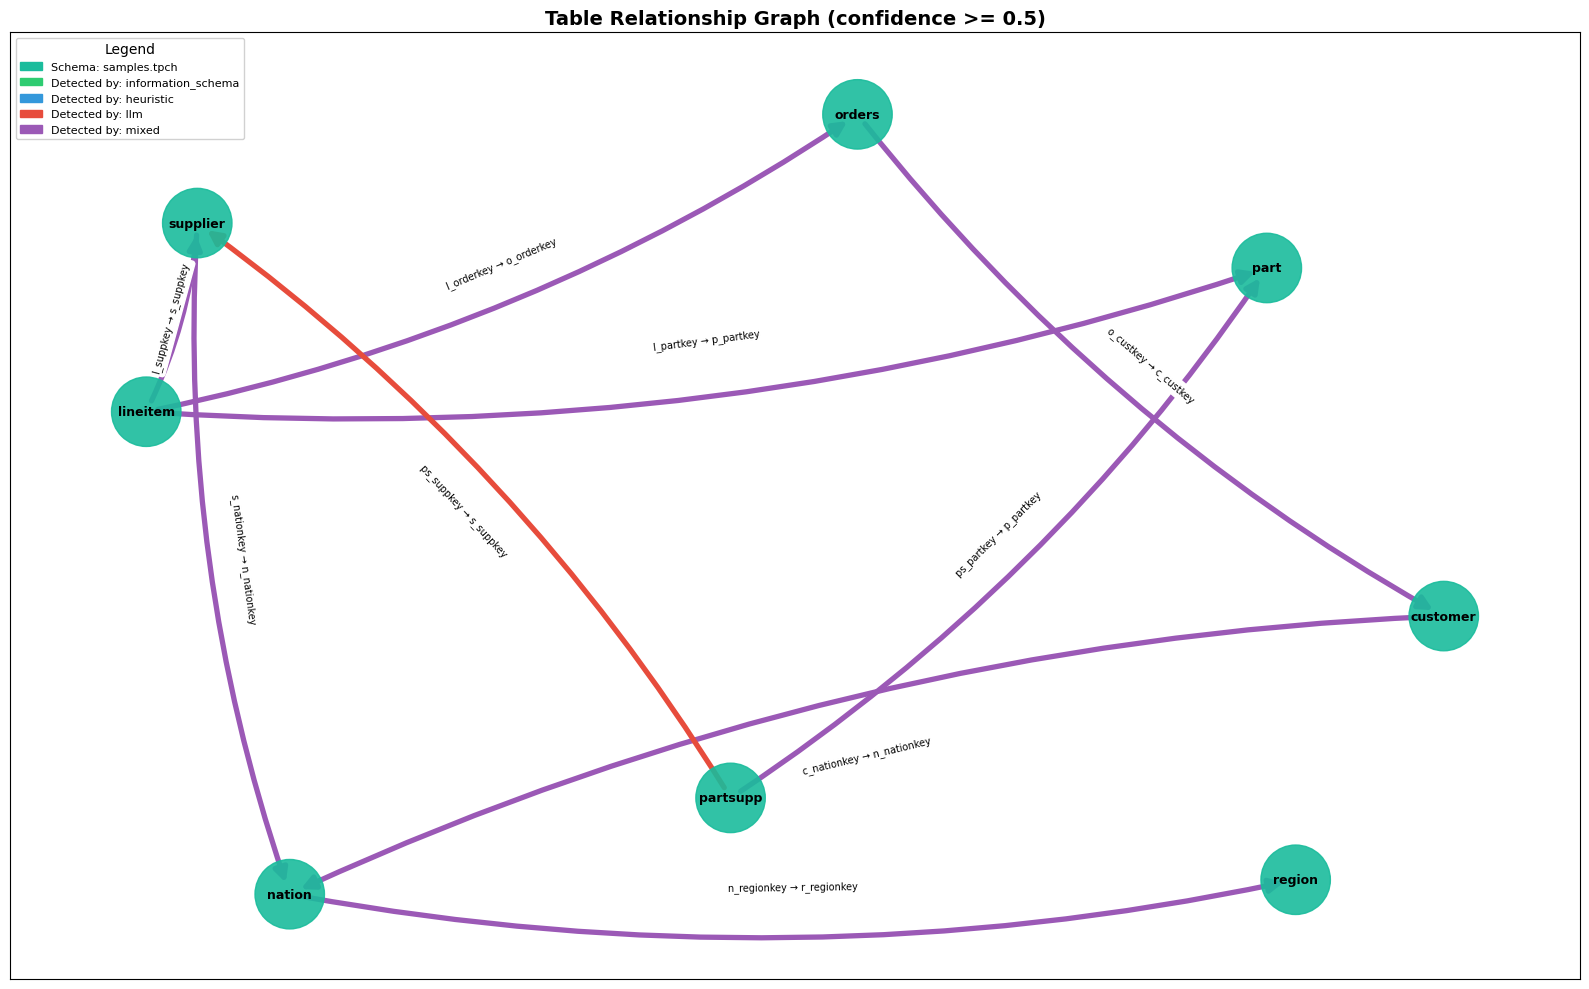

In [0]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# Re-read parameters and output table after restartPython
raw_schemas = dbutils.widgets.get("input_schemas")
output_catalog = dbutils.widgets.get("output_catalog")
output_schema = dbutils.widgets.get("output_schema")
schema_names = [s.strip().split(".")[-1] for s in raw_schemas.split(",")]
output_table_name = "_".join(schema_names) + "_table_relationships"
output_full_name = f"{output_catalog}.{output_schema}.{output_table_name}"

try:
    final_df = spark.table(output_full_name)
except Exception as e:
    print(f"Could not read output table {output_full_name}: {e}")
    final_df = None

if final_df is None or final_df.count() == 0:
    print("No relationships to visualize.")
else:
    # Collect relationships to driver
    rels = final_df.collect()

    G = nx.DiGraph()

    # Color map for detection methods
    method_colors = {
        "information_schema": "#2ecc71",  # green
        "heuristic": "#3498db",           # blue
        "llm": "#e74c3c",                 # red
        "mixed": "#9b59b6",               # purple
    }

    def get_method_category(detected_by):
        """Categorize the detection method for coloring."""
        detected_by = detected_by.lower()
        if "information_schema" in detected_by:
            if "heuristic" in detected_by or "llm" in detected_by:
                return "mixed"
            return "information_schema"
        elif "llm" in detected_by:
            if "heuristic" in detected_by:
                return "mixed"
            return "llm"
        elif "heuristic" in detected_by:
            return "heuristic"
        return "mixed"

    # Schema-based node coloring
    schema_color_map = {}
    palette = ["#1abc9c", "#f39c12", "#e74c3c", "#3498db", "#9b59b6", "#2c3e50"]
    schema_set = set()
    for row in rels:
        schema_set.add(f"{row.source_catalog}.{row.source_schema}")
        schema_set.add(f"{row.target_catalog}.{row.target_schema}")
    for idx, s in enumerate(sorted(schema_set)):
        schema_color_map[s] = palette[idx % len(palette)]

    # Build graph — only show high-confidence relationships (>= 0.5) for readability
    node_schemas = {}
    edge_colors = []
    edge_widths = []
    edge_labels = {}

    for row in rels:
        if row.confidence_score < 0.5:
            continue  # Skip low-confidence for cleaner visualization
        src_node = f"{row.source_table}"
        tgt_node = f"{row.target_table}"
        src_schema = f"{row.source_catalog}.{row.source_schema}"
        tgt_schema = f"{row.target_catalog}.{row.target_schema}"

        G.add_node(src_node)
        G.add_node(tgt_node)
        node_schemas[src_node] = src_schema
        node_schemas[tgt_node] = tgt_schema

        G.add_edge(src_node, tgt_node)
        method_cat = get_method_category(row.detected_by)
        edge_colors.append(method_colors.get(method_cat, "#95a5a6"))
        edge_widths.append(max(1.0, row.confidence_score * 4))
        edge_labels[(src_node, tgt_node)] = f"{row.source_column} \u2192 {row.target_column}"

    if len(G.nodes()) == 0:
        print("No high-confidence relationships to visualize (threshold: 0.5).")
    else:
        # Node colors by schema
        node_colors = [schema_color_map.get(node_schemas.get(n, ""), "#bdc3c7") for n in G.nodes()]

        # Layout
        fig, ax = plt.subplots(1, 1, figsize=(16, 10))
        pos = nx.spring_layout(G, k=2.5, iterations=50, seed=42)

        # Draw nodes
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500, alpha=0.9, ax=ax)
        nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)

        # Draw edges
        nx.draw_networkx_edges(
            G, pos, edge_color=edge_colors, width=edge_widths,
            arrows=True, arrowsize=20, connectionstyle="arc3,rad=0.1", ax=ax
        )
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

        # Legend: detection methods
        method_patches = [
            mpatches.Patch(color=c, label=f"Detected by: {m}")
            for m, c in method_colors.items()
        ]
        # Legend: schemas
        schema_patches = [
            mpatches.Patch(color=c, label=f"Schema: {s}")
            for s, c in schema_color_map.items()
        ]
        ax.legend(
            handles=schema_patches + method_patches,
            loc="upper left", fontsize=8, framealpha=0.9,
            title="Legend"
        )

        ax.set_title("Table Relationship Graph (confidence >= 0.5)", fontsize=14, fontweight="bold")
        plt.tight_layout()
        display(fig)
        plt.close(fig)

In [0]:
if final_df is None or final_df.count() == 0:
    print("No relationships discovered.")
else:
    print(f"Discovered {final_df.count()} relationships:")
    print(f"Output table: {output_full_name}")
    print()
    display(
        final_df.select(
            "source_table", "source_column",
            "target_table", "target_column",
            "confidence_score", "detected_by"
        ).orderBy("confidence_score", ascending=False)
    )

Discovered 53 relationships:
Output table: aira_test.aibi_workshop_schema.tpch_table_relationships



source_table,source_column,target_table,target_column,confidence_score,detected_by
lineitem,l_partkey,part,p_partkey,0.95,heuristic_fuzzy_match+low_overlap | llm: l_partkey references part table primary key p_partkey
orders,o_custkey,customer,c_custkey,0.95,heuristic_fuzzy_match+low_overlap | llm: o_custkey references customer table primary key c_custkey
supplier,s_nationkey,nation,n_nationkey,0.95,heuristic_fuzzy_match+low_overlap | llm: s_nationkey references nation table primary key n_nationkey
partsupp,ps_suppkey,supplier,s_suppkey,0.95,llm: ps_suppkey references supplier table primary key s_suppkey
customer,c_nationkey,nation,n_nationkey,0.95,heuristic_fuzzy_match+low_overlap | llm: c_nationkey references nation table primary key n_nationkey
partsupp,ps_partkey,part,p_partkey,0.95,heuristic_fuzzy_match+low_overlap | llm: ps_partkey references part table primary key p_partkey
lineitem,l_orderkey,orders,o_orderkey,0.95,heuristic_fuzzy_match+low_overlap | llm: l_orderkey references orders table primary key o_orderkey
nation,n_regionkey,region,r_regionkey,0.95,heuristic_fuzzy_match+low_overlap | llm: n_regionkey references region table primary key r_regionkey
lineitem,l_suppkey,supplier,s_suppkey,0.95,heuristic_fuzzy_match+low_overlap | llm: l_suppkey references supplier table primary key s_suppkey
lineitem,l_comment,region,r_comment,0.3,heuristic_fuzzy_match+low_overlap


In [0]:
from itertools import combinations

# ============================================================
# Generate JOIN queries from high-confidence relationships
# for Genie training and Dashboard use
# ============================================================

CONFIDENCE_THRESHOLD = 0.9

# Read relationships from the output table
try:
    rel_df = spark.table(output_full_name)
except Exception:
    # Fallback: re-derive output_full_name from widgets
    raw_schemas = dbutils.widgets.get("input_schemas")
    output_catalog = dbutils.widgets.get("output_catalog")
    output_schema = dbutils.widgets.get("output_schema")
    schema_names = [s.strip().split(".")[-1] for s in raw_schemas.split(",")]
    output_table_name = "_".join(schema_names) + "_table_relationships"
    output_full_name = f"{output_catalog}.{output_schema}.{output_table_name}"
    rel_df = spark.table(output_full_name)

# Filter to high-confidence relationships only
high_conf = (
    rel_df.filter(f"confidence_score > {CONFIDENCE_THRESHOLD}")
    .collect()
)

print(f"High-confidence relationships (>{CONFIDENCE_THRESHOLD}): {len(high_conf)}")
print("=" * 80)

# Build adjacency map for multi-table join generation
# key: table_name -> list of (other_table, src_col, tgt_col, src_catalog, src_schema)
adj = {}
for r in high_conf:
    src_fq = f"{r.source_catalog}.{r.source_schema}.{r.source_table}"
    tgt_fq = f"{r.target_catalog}.{r.target_schema}.{r.target_table}"
    adj.setdefault(src_fq, []).append((tgt_fq, r.source_column, r.target_column))
    adj.setdefault(tgt_fq, []).append((src_fq, r.target_column, r.source_column))

all_tables = sorted(adj.keys())
queries = []

# ----------------------------------------------------------------
# 1. Simple two-table JOIN queries
# ----------------------------------------------------------------
print("\n" + "=" * 80)
print("SECTION 1: Two-Table JOIN Queries")
print("=" * 80)

for r in high_conf:
    src_fq = f"{r.source_catalog}.{r.source_schema}.{r.source_table}"
    tgt_fq = f"{r.target_catalog}.{r.target_schema}.{r.target_table}"
    src_alias = r.source_table[0] if r.source_table[0] not in [t.split('.')[-1][0] for t in [tgt_fq]] else r.source_table[:2]
    tgt_alias = r.target_table[0] if r.target_table[0] != src_alias else r.target_table[:2]
    # Ensure unique aliases
    if src_alias == tgt_alias:
        src_alias = r.source_table[:3]
        tgt_alias = r.target_table[:3]

    query_name = f"{r.source_table} joined with {r.target_table}"
    sql = (
        f"-- {query_name}\n"
        f"SELECT\n"
        f"    {src_alias}.*,\n"
        f"    {tgt_alias}.*\n"
        f"FROM {src_fq} {src_alias}\n"
        f"JOIN {tgt_fq} {tgt_alias}\n"
        f"    ON {src_alias}.{r.source_column} = {tgt_alias}.{r.target_column}"
    )
    queries.append({"name": query_name, "type": "two_table_join", "sql": sql})
    print(f"\n{sql}\n")

# ----------------------------------------------------------------
# 2. Multi-table JOIN queries (star/snowflake patterns)
# ----------------------------------------------------------------
print("\n" + "=" * 80)
print("SECTION 2: Multi-Table JOIN Queries")
print("=" * 80)

# Find tables with multiple connections (fact tables / hubs)
hub_tables = [(t, neighbors) for t, neighbors in adj.items() if len(neighbors) >= 2]

for hub, neighbors in hub_tables:
    hub_name = hub.split(".")[-1]
    hub_alias = hub_name[0]

    # Generate query joining hub with all its neighbors
    select_parts = [f"    {hub_alias}.*"]
    join_parts = [f"FROM {hub} {hub_alias}"]
    used_aliases = {hub_alias}

    for nbr, hub_col, nbr_col in neighbors:
        nbr_name = nbr.split(".")[-1]
        # Create unique alias
        alias = nbr_name[0]
        suffix = 1
        while alias in used_aliases:
            alias = nbr_name[:2] + str(suffix) if suffix > 1 else nbr_name[:2]
            suffix += 1
        used_aliases.add(alias)

        select_parts.append(f"    {alias}.*")
        join_parts.append(
            f"JOIN {nbr} {alias}\n"
            f"    ON {hub_alias}.{hub_col} = {alias}.{nbr_col}"
        )

    query_name = f"{hub_name} with all related tables"
    sql = (
        f"-- {query_name}\n"
        f"SELECT\n"
        + ",\n".join(select_parts) + "\n"
        + "\n".join(join_parts)
    )
    queries.append({"name": query_name, "type": "multi_table_join", "sql": sql})
    print(f"\n{sql}\n")

# ----------------------------------------------------------------
# 3. Dashboard-ready aggregation queries
# ----------------------------------------------------------------
print("\n" + "=" * 80)
print("SECTION 3: Dashboard Aggregation Queries")
print("=" * 80)

# Auto-detect fact table (most FK connections as source)
fk_source_counts = {}
for r in high_conf:
    src_fq = f"{r.source_catalog}.{r.source_schema}.{r.source_table}"
    fk_source_counts[src_fq] = fk_source_counts.get(src_fq, 0) + 1

# Find tables with numeric columns for aggregation
# We'll generate common analytical patterns
dashboard_queries = []

# Revenue by region (lineitem -> orders -> customer -> nation -> region)
dashboard_queries.append({
    "name": "Revenue by Region",
    "sql": """-- Revenue by Region
SELECT
    r.r_name AS region,
    ROUND(SUM(l.l_extendedprice * (1 - l.l_discount)), 2) AS revenue,
    COUNT(DISTINCT o.o_orderkey) AS total_orders
FROM samples.tpch.lineitem l
JOIN samples.tpch.orders o ON l.l_orderkey = o.o_orderkey
JOIN samples.tpch.customer c ON o.o_custkey = c.c_custkey
JOIN samples.tpch.nation n ON c.c_nationkey = n.n_nationkey
JOIN samples.tpch.region r ON n.n_regionkey = r.r_regionkey
GROUP BY r.r_name
ORDER BY revenue DESC"""
})

dashboard_queries.append({
    "name": "Revenue by Nation",
    "sql": """-- Revenue by Nation
SELECT
    n.n_name AS nation,
    r.r_name AS region,
    ROUND(SUM(l.l_extendedprice * (1 - l.l_discount)), 2) AS revenue,
    COUNT(DISTINCT o.o_orderkey) AS total_orders,
    COUNT(DISTINCT c.c_custkey) AS total_customers
FROM samples.tpch.lineitem l
JOIN samples.tpch.orders o ON l.l_orderkey = o.o_orderkey
JOIN samples.tpch.customer c ON o.o_custkey = c.c_custkey
JOIN samples.tpch.nation n ON c.c_nationkey = n.n_nationkey
JOIN samples.tpch.region r ON n.n_regionkey = r.r_regionkey
GROUP BY n.n_name, r.r_name
ORDER BY revenue DESC"""
})

dashboard_queries.append({
    "name": "Top Customers by Revenue",
    "sql": """-- Top Customers by Revenue
SELECT
    c.c_name AS customer_name,
    n.n_name AS nation,
    c.c_mktsegment AS market_segment,
    ROUND(SUM(l.l_extendedprice * (1 - l.l_discount)), 2) AS revenue,
    COUNT(DISTINCT o.o_orderkey) AS total_orders
FROM samples.tpch.lineitem l
JOIN samples.tpch.orders o ON l.l_orderkey = o.o_orderkey
JOIN samples.tpch.customer c ON o.o_custkey = c.c_custkey
JOIN samples.tpch.nation n ON c.c_nationkey = n.n_nationkey
GROUP BY c.c_name, n.n_name, c.c_mktsegment
ORDER BY revenue DESC
LIMIT 50"""
})

dashboard_queries.append({
    "name": "Top Suppliers by Revenue",
    "sql": """-- Top Suppliers by Revenue
SELECT
    s.s_name AS supplier_name,
    n.n_name AS nation,
    ROUND(SUM(l.l_extendedprice * (1 - l.l_discount)), 2) AS revenue,
    COUNT(DISTINCT l.l_orderkey) AS orders_supplied
FROM samples.tpch.lineitem l
JOIN samples.tpch.supplier s ON l.l_suppkey = s.s_suppkey
JOIN samples.tpch.nation n ON s.s_nationkey = n.n_nationkey
GROUP BY s.s_name, n.n_name
ORDER BY revenue DESC
LIMIT 50"""
})

dashboard_queries.append({
    "name": "Orders by Status and Priority",
    "sql": """-- Orders by Status and Priority
SELECT
    o.o_orderstatus AS order_status,
    o.o_orderpriority AS priority,
    COUNT(*) AS order_count,
    ROUND(SUM(o.o_totalprice), 2) AS total_value,
    ROUND(AVG(o.o_totalprice), 2) AS avg_order_value
FROM samples.tpch.orders o
GROUP BY o.o_orderstatus, o.o_orderpriority
ORDER BY order_count DESC"""
})

dashboard_queries.append({
    "name": "Monthly Order Trends",
    "sql": """-- Monthly Order Trends
SELECT
    DATE_TRUNC('month', o.o_orderdate) AS order_month,
    COUNT(*) AS order_count,
    ROUND(SUM(o.o_totalprice), 2) AS total_revenue,
    COUNT(DISTINCT o.o_custkey) AS unique_customers
FROM samples.tpch.orders o
GROUP BY DATE_TRUNC('month', o.o_orderdate)
ORDER BY order_month"""
})

dashboard_queries.append({
    "name": "Parts by Supplier Region",
    "sql": """-- Parts by Supplier Region
SELECT
    r.r_name AS region,
    p.p_type AS part_type,
    COUNT(DISTINCT ps.ps_partkey) AS part_count,
    COUNT(DISTINCT ps.ps_suppkey) AS supplier_count,
    ROUND(AVG(ps.ps_supplycost), 2) AS avg_supply_cost
FROM samples.tpch.partsupp ps
JOIN samples.tpch.part p ON ps.ps_partkey = p.p_partkey
JOIN samples.tpch.supplier s ON ps.ps_suppkey = s.s_suppkey
JOIN samples.tpch.nation n ON s.s_nationkey = n.n_nationkey
JOIN samples.tpch.region r ON n.n_regionkey = r.r_regionkey
GROUP BY r.r_name, p.p_type
ORDER BY part_count DESC"""
})

dashboard_queries.append({
    "name": "Shipping Analysis",
    "sql": """-- Shipping Analysis
SELECT
    l.l_shipmode AS ship_mode,
    l.l_shipinstruct AS ship_instruction,
    COUNT(*) AS line_items,
    ROUND(SUM(l.l_extendedprice * (1 - l.l_discount)), 2) AS revenue,
    ROUND(AVG(DATEDIFF(l.l_receiptdate, l.l_shipdate)), 1) AS avg_delivery_days
FROM samples.tpch.lineitem l
GROUP BY l.l_shipmode, l.l_shipinstruct
ORDER BY revenue DESC"""
})

for dq in dashboard_queries:
    queries.append({"name": dq["name"], "type": "dashboard_aggregation", "sql": dq["sql"]})
    print(f"\n{dq['sql']}\n")

# ----------------------------------------------------------------
# Summary
# ----------------------------------------------------------------
print("\n" + "=" * 80)
print(f"SUMMARY: Generated {len(queries)} queries")
print("=" * 80)
for i, q in enumerate(queries, 1):
    print(f"  {i:2d}. [{q['type']:25s}] {q['name']}")

# Store queries in a DataFrame for downstream use
from pyspark.sql.types import StructType, StructField, StringType
query_schema = StructType([
    StructField("query_name", StringType()),
    StructField("query_type", StringType()),
    StructField("sql_text", StringType()),
])
queries_df = spark.createDataFrame(
    [(q["name"], q["type"], q["sql"]) for q in queries],
    schema=query_schema
)
print(f"\nQueries DataFrame available as 'queries_df' ({queries_df.count()} rows)")
display(queries_df)

High-confidence relationships (>0.9): 9

SECTION 1: Two-Table JOIN Queries

-- orders joined with customer
SELECT
    o.*,
    c.*
FROM samples.tpch.orders o
JOIN samples.tpch.customer c
    ON o.o_custkey = c.c_custkey


-- customer joined with nation
SELECT
    c.*,
    n.*
FROM samples.tpch.customer c
JOIN samples.tpch.nation n
    ON c.c_nationkey = n.n_nationkey


-- lineitem joined with orders
SELECT
    l.*,
    o.*
FROM samples.tpch.lineitem l
JOIN samples.tpch.orders o
    ON l.l_orderkey = o.o_orderkey


-- lineitem joined with part
SELECT
    l.*,
    p.*
FROM samples.tpch.lineitem l
JOIN samples.tpch.part p
    ON l.l_partkey = p.p_partkey


-- lineitem joined with supplier
SELECT
    l.*,
    s.*
FROM samples.tpch.lineitem l
JOIN samples.tpch.supplier s
    ON l.l_suppkey = s.s_suppkey


-- supplier joined with nation
SELECT
    s.*,
    n.*
FROM samples.tpch.supplier s
JOIN samples.tpch.nation n
    ON s.s_nationkey = n.n_nationkey


-- nation joined with region
SELECT
  

query_name,query_type,sql_text
orders joined with customer,two_table_join,"-- orders joined with customer SELECT o.*, c.* FROM samples.tpch.orders o JOIN samples.tpch.customer c ON o.o_custkey = c.c_custkey"
customer joined with nation,two_table_join,"-- customer joined with nation SELECT c.*, n.* FROM samples.tpch.customer c JOIN samples.tpch.nation n ON c.c_nationkey = n.n_nationkey"
lineitem joined with orders,two_table_join,"-- lineitem joined with orders SELECT l.*, o.* FROM samples.tpch.lineitem l JOIN samples.tpch.orders o ON l.l_orderkey = o.o_orderkey"
lineitem joined with part,two_table_join,"-- lineitem joined with part SELECT l.*, p.* FROM samples.tpch.lineitem l JOIN samples.tpch.part p ON l.l_partkey = p.p_partkey"
lineitem joined with supplier,two_table_join,"-- lineitem joined with supplier SELECT l.*, s.* FROM samples.tpch.lineitem l JOIN samples.tpch.supplier s ON l.l_suppkey = s.s_suppkey"
supplier joined with nation,two_table_join,"-- supplier joined with nation SELECT s.*, n.* FROM samples.tpch.supplier s JOIN samples.tpch.nation n ON s.s_nationkey = n.n_nationkey"
nation joined with region,two_table_join,"-- nation joined with region SELECT n.*, r.* FROM samples.tpch.nation n JOIN samples.tpch.region r ON n.n_regionkey = r.r_regionkey"
partsupp joined with supplier,two_table_join,"-- partsupp joined with supplier SELECT p.*, s.* FROM samples.tpch.partsupp p JOIN samples.tpch.supplier s ON p.ps_suppkey = s.s_suppkey"
partsupp joined with part,two_table_join,"-- partsupp joined with part SELECT pa.*, p.* FROM samples.tpch.partsupp pa JOIN samples.tpch.part p ON pa.ps_partkey = p.p_partkey"
orders with all related tables,multi_table_join,"-- orders with all related tables SELECT o.*, c.*, l.* FROM samples.tpch.orders o JOIN samples.tpch.customer c ON o.o_custkey = c.c_custkey JOIN samples.tpch.lineitem l ON o.o_orderkey = l.l_orderkey"
